<a href="https://colab.research.google.com/github/sdhnr/sdhnr/blob/main/ML1_Final_Project_Telecom_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom Customer Churn Prediction
## BIA 5302 Machine Learning 1 Final Project

### Group Members
- Said Huner
- Georgina Armand
- Joel Biju Mathen
- Eyimofe Boyo
- Seynab Urur

## Importing Libraries
In this section, the required Python libraries are imported to support data exploration, preprocessing, visualization, model training, and performance evaluation.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV


## 1. Project Background and Objective

## 2. Dataset Overview

In [3]:
telcom_df = pd.read_csv('/content/churn-bigml-80.csv')
telcom_test_df = pd.read_csv('/content/churn-bigml-20.csv')

In [4]:
telcom_df.head(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [5]:
def data_overview(df, message):
    print(f"\n{'='*50}")
    print(f"{message}")
    print(f"{'='*50}")

    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")

    print("\nColumn Names:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())
    print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

    print(f"\nDuplicate Rows: {df.duplicated().sum()}")

    print("\nNumber of Unique Values per Column:")
    print(df.nunique())

    print("\nFirst 5 Rows:")
    print(df.head())

In [6]:
data_overview(telcom_df, "Training Dataset Overview")


Training Dataset Overview
Rows: 2666
Columns: 20

Column Names:
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

Data Types:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes   

In [7]:
data_overview(telcom_test_df, "Test Dataset Overview")


Test Dataset Overview
Rows: 667
Columns: 20

Column Names:
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

Data Types:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        

In [8]:
print("Training target distribution:")
print(telcom_df['Churn'].value_counts())
print("\nTraining target proportion:")
print(telcom_df['Churn'].value_counts(normalize=True))

Training target distribution:
Churn
False    2278
True      388
Name: count, dtype: int64

Training target proportion:
Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64


## 3. Data Preprocessing
In this section, redundant features were removed, categorical variables were encoded, and the data was prepared for machine learning. The charge-related columns were dropped because they are directly derived from the corresponding call-minute variables, which would create redundancy. Binary categorical features were label encoded, and scaled and unscaled versions of the predictor dataset were prepared to support different machine learning algorithms.

To reduce redundancy among predictors, highly related charge variables were removed because they are directly calculated from their corresponding minute-based usage variables. This helps simplify the feature space and reduces multicollinearity before model training.

In [9]:
# Make copies so the original datasets stay unchanged
train_df = telcom_df.copy()
test_df = telcom_test_df.copy()

# Drop redundant charge columns
# These are directly derived from the corresponding minute columns
columns_to_drop = ['Total day charge', 'Total eve charge', 'Total night charge', 'Total intl charge']
train_df = train_df.drop(columns=columns_to_drop)
test_df = test_df.drop(columns=columns_to_drop)

# Drop State and Area code for a simpler preprocessing
# State has many categories and Area code behaves more like a label than a true numeric feature
train_df = train_df.drop(columns=['State', 'Area code'])
test_df = test_df.drop(columns=['State', 'Area code'])

# Encode binary categorical columns
binary_cols = ['International plan', 'Voice mail plan']

for col in binary_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

# Convert target column from True/False to 0/1
train_df['Churn'] = train_df['Churn'].astype(int)
test_df['Churn'] = test_df['Churn'].astype(int)

# Separate input and output variables
X_train = train_df.drop(columns=['Churn'])
y_train = train_df['Churn']

X_test = test_df.drop(columns=['Churn'])
y_test = test_df['Churn']

# Keep an unscaled version for tree-based models
X_train_unscaled = X_train.copy()
X_test_unscaled = X_test.copy()

# Scale numerical features for models sensitive to feature scale
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Final shape check
print("X_train_unscaled shape:", X_train_unscaled.shape)
print("X_test_unscaled shape:", X_test_unscaled.shape)
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train_unscaled shape: (2666, 13)
X_test_unscaled shape: (667, 13)
X_train_scaled shape: (2666, 13)
X_test_scaled shape: (667, 13)
y_train shape: (2666,)
y_test shape: (667,)


In [10]:
print(X_train_unscaled.shape)
print(X_test_unscaled.shape)
print(X_train_scaled.shape)
print(X_test_scaled.shape)

print(y_train.value_counts())
print(y_test.value_counts())

print(X_train_unscaled.head())

(2666, 13)
(667, 13)
(2666, 13)
(667, 13)
Churn
0    2278
1     388
Name: count, dtype: int64
Churn
0    572
1     95
Name: count, dtype: int64
   Account length  International plan  Voice mail plan  Number vmail messages  \
0             128                   0                1                     25   
1             107                   0                1                     26   
2             137                   0                0                      0   
3              84                   1                0                      0   
4              75                   1                0                      0   

   Total day minutes  Total day calls  Total eve minutes  Total eve calls  \
0              265.1              110              197.4               99   
1              161.6              123              195.5              103   
2              243.4              114              121.2              110   
3              299.4               71               61.9     

In [11]:
print(X_train_unscaled.dtypes) # all features are numeric.

Account length              int64
International plan          int64
Voice mail plan             int64
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total eve minutes         float64
Total eve calls             int64
Total night minutes       float64
Total night calls           int64
Total intl minutes        float64
Total intl calls            int64
Customer service calls      int64
dtype: object


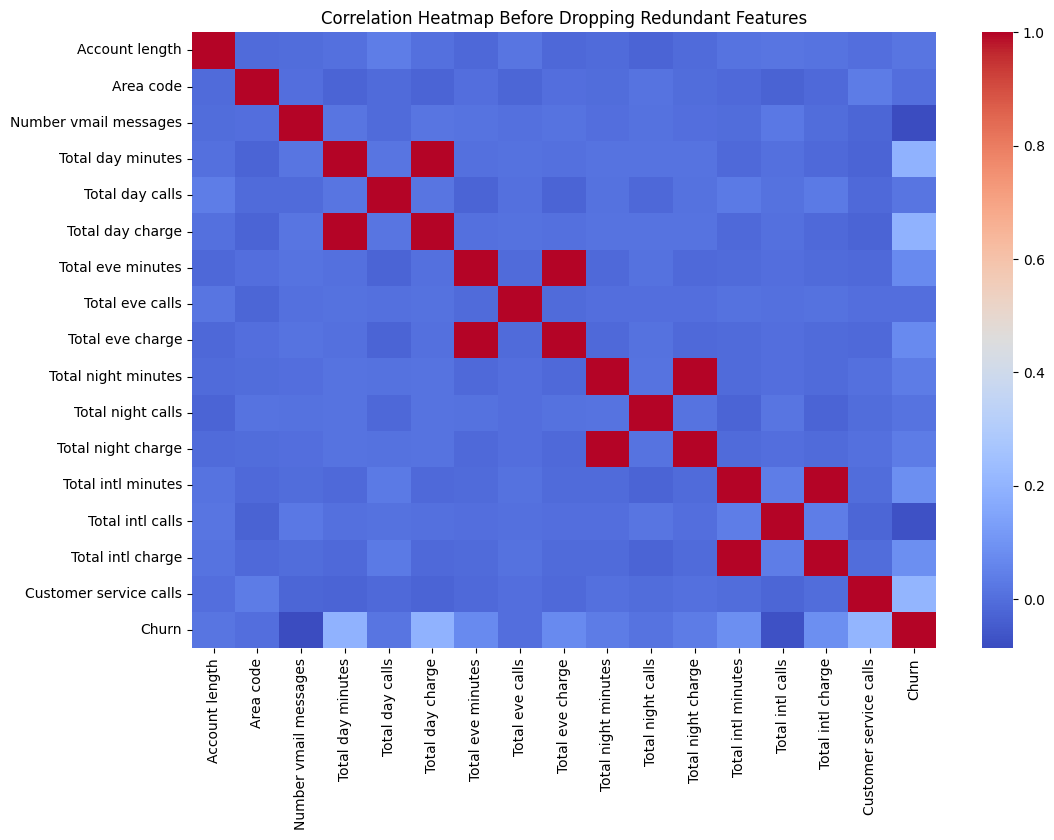

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(telcom_df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap Before Dropping Redundant Features")
plt.show()

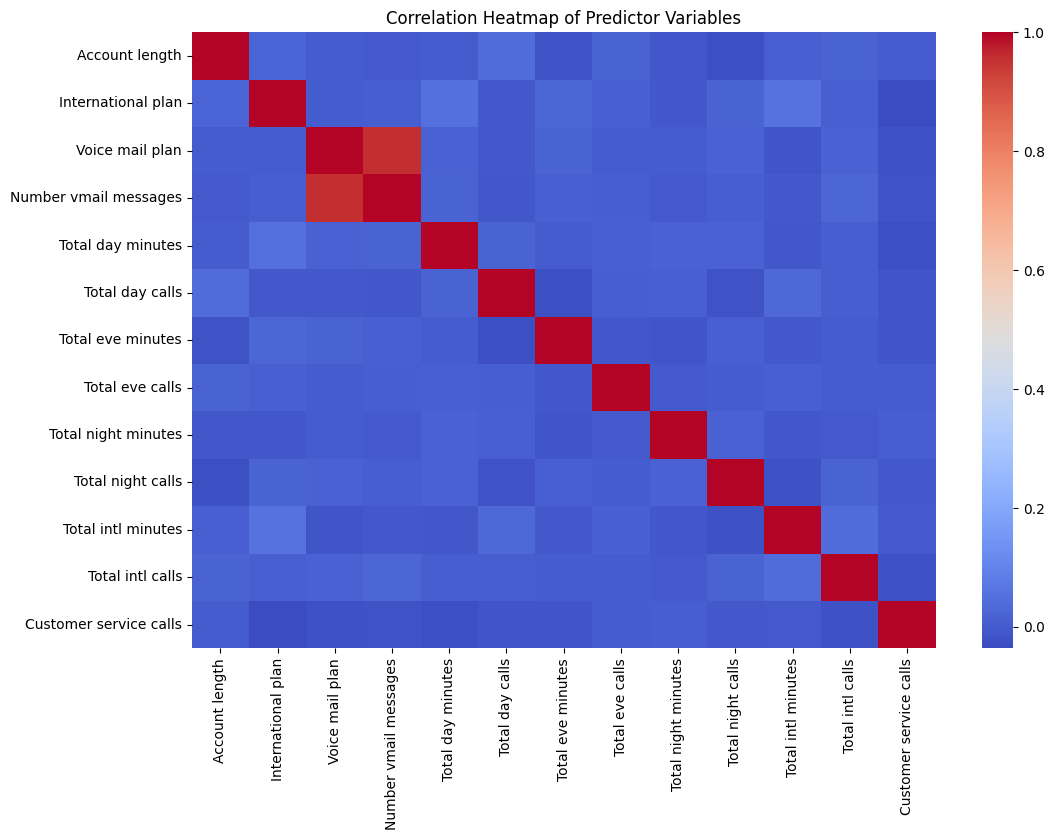

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(X_train_unscaled.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap of Predictor Variables")
plt.show()

After removing the charge-related features, the strongest multicollinearity issue was largely reduced. A moderate relationship still appears between `Voice mail plan` and `Number vmail messages`, which is expected because customers with a voice mail plan are more likely to have voice mail messages recorded. However, this remaining correlation is not as severe as the original redundancy between the minute and charge variables.

Before building the machine learning models, the dataset was preprocessed to make it suitable for analysis and prediction.

First, the training and test datasets were loaded and examined to understand their structure, variable types, and overall quality. During this inspection, no missing values and no duplicate rows were found in either dataset. This meant that no imputation or duplicate removal was required.

Next, several columns were reviewed for redundancy and usefulness. The variables `Total day charge`, `Total eve charge`, `Total night charge`, and `Total intl charge` were dropped because they are directly derived from their corresponding minute-based variables. Keeping both the minute and charge columns would introduce redundant information and increase multicollinearity in the dataset.

The columns `State` and `Area code` were also removed to simplify the preprocessing pipeline. `State` contains many categories, which would create a large number of dummy variables, while `Area code` behaves more like a categorical identifier than a meaningful continuous predictor in this analysis.

After that, the binary categorical variables `International plan` and `Voice mail plan` were converted into numerical form using label encoding. This step was necessary because machine learning algorithms require numerical input. The target variable `Churn`, which originally appeared in boolean format, was also converted into binary form where 1 represents churn and 0 represents non-churn.

Then, the dataset was divided into predictor variables and the target variable. The predictors were stored in `X_train` and `X_test`, while the target was stored in `y_train` and `y_test`.

Finally, numerical predictor variables were standardized using `StandardScaler`. This was done to create scaled versions of the data for algorithms that are sensitive to feature magnitude, such as K-Nearest Neighbors and Support Vector Machine. At the same time, unscaled versions of the dataset were also preserved for tree-based models such as Decision Tree and Random Forest, since these models do not require scaling.

As a result of these preprocessing steps, the telecom churn data was transformed into a clean and machine-learning-ready format for the modeling stage.

### Justification for Dropped Columns

Some variables were removed during preprocessing to reduce redundancy and simplify the model input.

- `Total day charge`, `Total eve charge`, `Total night charge`, and `Total intl charge` were dropped because they are directly calculated from the corresponding minute-based variables. Keeping both sets of variables would add overlapping information and increase multicollinearity.
- `State` was dropped because it contains many categories, which would unnecessarily increase dimensionality in the dataset.
- `Area code` was dropped because it functions more as a categorical identifier than as a strong predictive numerical feature.

At the end of preprocessing, the dataset was converted into a clean and model-ready format. Both scaled and unscaled versions of the predictor variables were prepared so that different machine learning algorithms could be applied appropriately in the next stage.

## 4. Exploratory Data Analysis

## 5. Model Building

In this section, multiple machine learning classification algorithms are trained and tested to predict customer churn. Since different algorithms respond differently to feature scaling, both scaled and unscaled datasets are used where appropriate. The selected models are compared based on their predictive performance on the test dataset.

In [15]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Model: {model_name}")
    print("-" * 50)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_pred)
    }

In [18]:
#logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg_results = evaluate_model(log_reg, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression")

Model: Logistic Regression
--------------------------------------------------
Accuracy: 0.8545727136431784
ROC-AUC: 0.5772543246227456

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       572
           1       0.47      0.19      0.27        95

    accuracy                           0.85       667
   macro avg       0.68      0.58      0.59       667
weighted avg       0.82      0.85      0.83       667


Confusion Matrix:
[[552  20]
 [ 77  18]]




In [19]:
#knn
knn = KNeighborsClassifier(n_neighbors=5)
knn_results = evaluate_model(knn, X_train_scaled, X_test_scaled, y_train, y_test, "K-Nearest Neighbors")

Model: K-Nearest Neighbors
--------------------------------------------------
Accuracy: 0.8905547226386806
ROC-AUC: 0.6465126978284874

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       572
           1       0.81      0.31      0.44        95

    accuracy                           0.89       667
   macro avg       0.85      0.65      0.69       667
weighted avg       0.88      0.89      0.87       667


Confusion Matrix:
[[565   7]
 [ 66  29]]




In [20]:
#Decision tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_results = evaluate_model(dt, X_train_unscaled, X_test_unscaled, y_train, y_test, "Decision Tree")

Model: Decision Tree
--------------------------------------------------
Accuracy: 0.952023988005997
ROC-AUC: 0.8886363636363637

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       572
           1       0.85      0.80      0.83        95

    accuracy                           0.95       667
   macro avg       0.91      0.89      0.90       667
weighted avg       0.95      0.95      0.95       667


Confusion Matrix:
[[559  13]
 [ 19  76]]




In [21]:
#Random forest
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_results = evaluate_model(rf, X_train_unscaled, X_test_unscaled, y_train, y_test, "Random Forest")

Model: Random Forest
--------------------------------------------------
Accuracy: 0.9415292353823088
ROC-AUC: 0.8035149061464851

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       572
           1       0.97      0.61      0.75        95

    accuracy                           0.94       667
   macro avg       0.95      0.80      0.86       667
weighted avg       0.94      0.94      0.94       667


Confusion Matrix:
[[570   2]
 [ 37  58]]




In [23]:
#SVM
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_results = evaluate_model(svm_model, X_train_scaled, X_test_scaled, y_train, y_test, "Support Vector Machine")

Model: Support Vector Machine
--------------------------------------------------
Accuracy: 0.9205397301349325
ROC-AUC: 0.7429977916820022

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       572
           1       0.90      0.49      0.64        95

    accuracy                           0.92       667
   macro avg       0.91      0.74      0.80       667
weighted avg       0.92      0.92      0.91       667


Confusion Matrix:
[[567   5]
 [ 48  47]]




## 6. Model Evaluation and Comparison

In [30]:
results_df = pd.DataFrame([
    log_reg_results,
    knn_results,
    dt_results,
    rf_results,
    svm_results
])

results_df

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.854573,0.577254
1,K-Nearest Neighbors,0.890555,0.646513
2,Decision Tree,0.952024,0.888636
3,Random Forest,0.941529,0.803515
4,Support Vector Machine,0.920540,0.742998


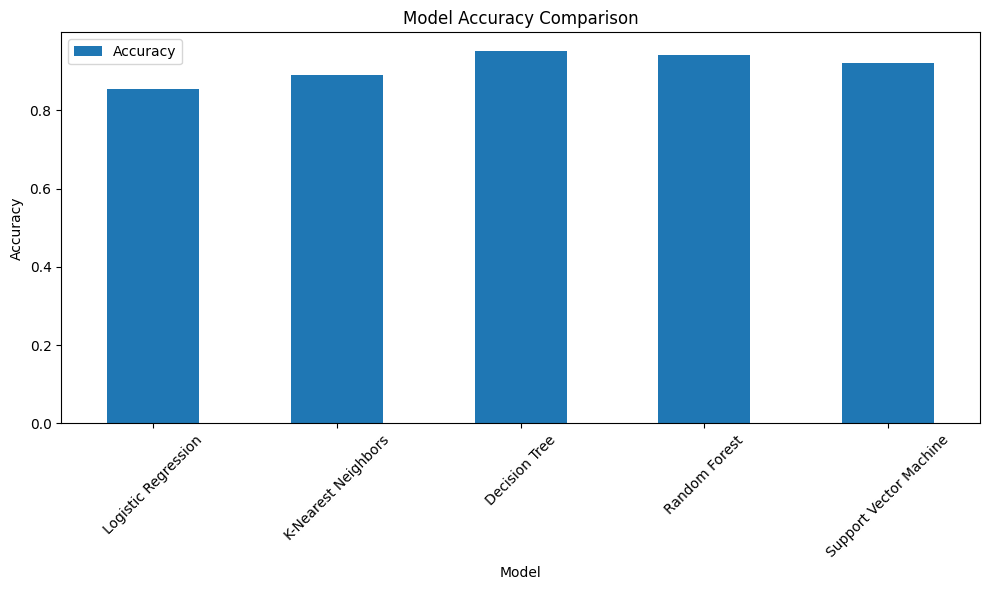

In [31]:
import matplotlib.pyplot as plt

results_df.plot(x='Model', y='Accuracy', kind='bar', figsize=(10,6))
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

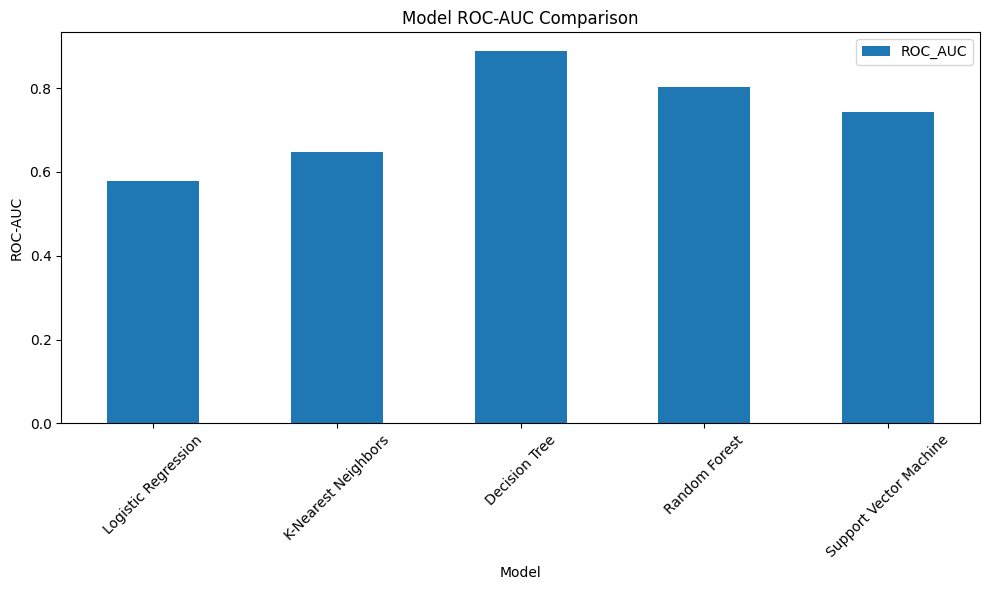

In [32]:
results_df.plot(x='Model', y='ROC_AUC', kind='bar', figsize=(10,6))
plt.title('Model ROC-AUC Comparison')
plt.ylabel('ROC-AUC')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [33]:
best_model = DecisionTreeClassifier(max_depth=5, random_state=42)
best_model.fit(X_train_unscaled, y_train)

y_pred_best = best_model.predict(X_test_unscaled)

print("Best Model: Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

Best Model: Decision Tree
Accuracy: 0.952023988005997
ROC-AUC: 0.8886363636363637

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       572
           1       0.85      0.80      0.83        95

    accuracy                           0.95       667
   macro avg       0.91      0.89      0.90       667
weighted avg       0.95      0.95      0.95       667


Confusion Matrix:
[[559  13]
 [ 19  76]]


In [39]:
y_prob_best = best_model.predict_proba(X_test_unscaled)[:, 1]

prediction_demo = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_best,
    'Predicted_Probability_Churn': y_prob_best
})

prediction_demo['Actual'] = prediction_demo['Actual'].map({0: 'Not Churn', 1: 'Churn'})
prediction_demo['Predicted'] = prediction_demo['Predicted'].map({0: 'Not Churn', 1: 'Churn'})

prediction_demo['Result'] = np.where(
    prediction_demo['Actual'] == prediction_demo['Predicted'],
    'Correct',
    'Incorrect'
)

prediction_demo.head(20)

,Actual,Predicted,Predicted_Probability_Churn,Result
0,Not Churn,Not Churn,0.026966,Correct
1,Churn,Churn,0.777778,Correct
2,Churn,Churn,1.000000,Correct
3,Not Churn,Not Churn,0.026966,Correct
4,Not Churn,Not Churn,0.026966,Correct
5,Not Churn,Not Churn,0.026966,Correct
6,Not Churn,Not Churn,0.026966,Correct
7,Churn,Not Churn,0.000000,Incorrect
8,Not Churn,Not Churn,0.026966,Correct
9,Not Churn,Not Churn,0.026966,Correct


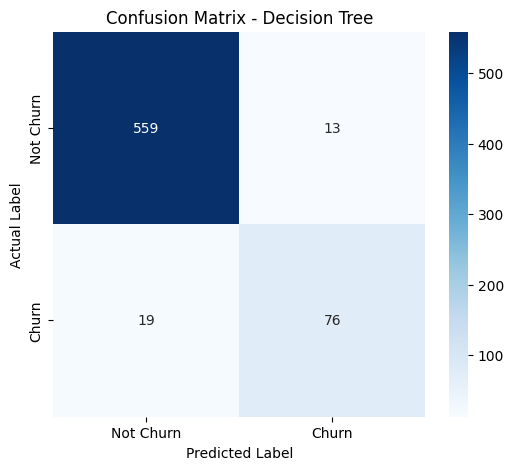

In [34]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

Among the five tested algorithms, the Decision Tree model produced the best overall performance. It achieved the highest Accuracy and the highest ROC-AUC score, which indicates that it was the most effective model for distinguishing between churn and non-churn customers in this dataset.

The results show that tree-based models performed better than the other algorithms in this project. In particular, the Decision Tree model captured the patterns in the telecom churn data more effectively than Logistic Regression, K-Nearest Neighbors, Random Forest, and Support Vector Machine. This suggests that the relationship between customer features and churn may involve nonlinear decision patterns that are well handled by tree-based methods.
#### Hyperparameter Justification
The hyperparameters were selected as reasonable starting values for each algorithm. Logistic Regression used a higher iteration limit to ensure convergence. KNN used 5 neighbors as a common baseline choice. Decision Tree used a restricted depth to reduce overfitting. Random Forest used 100 trees to provide stable ensemble performance. Support Vector Machine used the RBF kernel to capture nonlinear patterns in the data.

### GridSeachCv Hyperparameter tuning


In [36]:
dt_param_grid = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

dt_grid.fit(X_train_unscaled, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best Cross-Validation ROC-AUC:", dt_grid.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Cross-Validation ROC-AUC: 0.8939942317017214


In [37]:
best_dt_tuned = dt_grid.best_estimator_

dt_tuned_results = evaluate_model(
    best_dt_tuned,
    X_train_unscaled,
    X_test_unscaled,
    y_train,
    y_test,
    "Tuned Decision Tree"
)

Model: Tuned Decision Tree
--------------------------------------------------
Accuracy: 0.9415292353823088
ROC-AUC: 0.8737394184762606

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       572
           1       0.80      0.78      0.79        95

    accuracy                           0.94       667
   macro avg       0.88      0.87      0.88       667
weighted avg       0.94      0.94      0.94       667


Confusion Matrix:
[[554  18]
 [ 21  74]]




In [38]:
comparison_df = pd.DataFrame([
    dt_results,
    dt_tuned_results
])

comparison_df

,Model,Accuracy,ROC_AUC
0,Decision Tree,0.952024,0.888636
1,Tuned Decision Tree,0.941529,0.873739


The tuned Decision Tree performed slightly worse than the baseline model because hyperparameter tuning does not always guarantee better results on unseen test data. GridSearchCV selects the best parameter combination based on cross-validation performance within the training data, but that combination may not generalize better to the separate test dataset.

In this case, the original baseline Decision Tree may have matched the structure of the telecom churn data more effectively, while the tuned version may have become slightly less suitable for the final test set. Small changes in parameters such as tree depth, minimum samples per split, or minimum samples per leaf can affect how the model captures patterns in the data. If those settings become too restrictive or not well aligned with the dataset, performance can decrease.

Therefore, even though hyperparameter tuning was applied correctly, the baseline Decision Tree remained the stronger model. This shows that tuning is an important step for testing model improvement, but the final model should always be selected based on actual evaluation results rather than assuming the tuned version will automatically be better.

## 7. Conclusion

This project applied five machine learning classification models to predict telecom customer churn. After preprocessing the data and comparing model performance, the Decision Tree model was selected as the best-performing algorithm based on Accuracy and ROC-AUC.

The findings suggest that customer and service-related variables can be used effectively to predict churn. Such predictions can help telecom companies identify at-risk customers early and take preventive actions to improve retention and reduce customer loss.

Overall, the project demonstrates how machine learning can support business decision-making in customer relationship management and churn prevention.